# K-means


In [1]:
# Установка зависимостей
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# Загрузка датасета
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

df.head()

,id,year_birth,education,marital_status,income,kids,date_first_purchase,days_since_last_purchase,num_purchases_at_shop,num_web_purchases,avg_purchase_sum
0,486,1993,Graduation,Married,33069.1,0,15-11-2012,113,1,1,36.9
1,6690,1971,Basic,Widow,98707.1,2,21-08-2013,19,10,4,283.2
2,7101,1995,Graduation,Married,34859.8,0,31-07-2012,120,2,1,31.2
3,1357,1984,Master,Single,69317.6,1,30-06-2013,61,3,8,114.1
4,10785,1998,Basic,Divorced,122592.0,5,08-04-2014,178,2,2,52.1


In [4]:
# Отбор признаков (id и даты не используются)
num_cols = [
    "income", "kids",
    "days_since_last_purchase", "num_purchases_at_shop",
    "num_web_purchases", "avg_purchase_sum"
]
cat_cols = ["education", "marital_status"]

# Формирование датасета X - только нужные колонки
X = df[num_cols + cat_cols].copy() 

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Препроцессинг:
#   - масштабирование числовых признаков с помощью StandardScaler
#   - OneHotEncoder для категориальных признаков
numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

# Применение трансформера к данным
X_tr = preprocess.fit_transform(X)

In [6]:
# Импорт K-Means

from sklearn.cluster import KMeans

# K-Means
pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("kmeans", KMeans(n_clusters=3, random_state=42)),
]).fit(X) 

In [7]:
# Результаты
print(f"Кластеры: {pipe['kmeans'].labels_}")
print(f"Центры кластеров: {pipe['kmeans'].cluster_centers_}")

Кластеры: [2 1 2 1 1 1 0 1 2 1 1 0 2 0 1 1 1 1 1 1 1 1 1 2 2 2 1 0 1 1 1 1 1 2 1 1 0
 1 1 2 0 1 1 2 1 1 1 1 0 2 0 1 0 1 2 2 0 2 2 0 2 2 1 2 0 1 1 0 0 1 2 2 0 0
 2 1 2 1 0 1 2 1 2 0 1 1 1 2 2 0 1 1 1 1 0 1 2 2 1 1 2 2 1 2 0 2 2 1 1 2 2
 2 0 1 2 1 1 1 1 0 0 1 0 0 0 2 1 1 1 1 2 0 1 0 1 2 1 0 1 1 1 0 1 0 1 0 1 1
 2 2 1 2 1 1 1 2 1 2 0 2 2 0 1 1 0 2 2 1 0 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 2
 1 1 1 2 2 1 1 1 2 1 0 2 1 1 2 0 0 2 2 0 1 1 1 1 1 1 1 1 1 1 1 0 0 2 2 2 1
 2 2 0 1 1 0 1 1 0 2 1 1 0 0 0 2 0 2 1 1 0 0 1 1 0 2 1 0 1 1 1 1 2 1 2 1 1
 2 1 2 2 1 0 0 1 2 1 1 2 1 0 1 2 0 1 2 0 1 1 1 1 1 2 1 0 1 1 0 1 1 0 2 0 0
 1 2 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 2 1 2 0 1 2 0 1 1 1 0 1 0 1 1 0 0 2 2 0
 1 1 2 0 0 1 1 2 1 1 0 0 1 1 2 1 1 0 1 0 2 0 0 1 1 1 1 2 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 2 0 0 1 1 2 0
 1 2 1 0 2 1 1 1 2 0 1 1 2 1 1 1 1 1 1 1 0 1 1 1 1 2 2 1 0 0 1 1 1 1 2 1 0
 0 0 1 2 1 1 1 1 2 2 1 0 2 1 1 1 1 1 1 1 2 1 1 1 2 2 0 1 0 2 1 1 1 2 2 2 1
 1 2 1 1 0 2 0 

In [8]:
pipe['kmeans'].inertia_

1554.2011978846324

In [9]:
np.tril(np.ones((3, 3), dtype=bool), k=-1)

array([[False, False, False],
       [ True, False, False],
       [ True,  True, False]])

In [10]:
from sklearn.metrics import pairwise_distances

mask = np.tril(np.ones((3, 3), dtype=bool), k=-1)
pairwise_distances(pipe['kmeans'].cluster_centers_, metric="euclidean")[mask]

array([3.63155184, 5.71849564, 3.44932798])

## Силуэтный коэффициент

In [11]:
X_tr = preprocess.fit_transform(X) 

In [12]:
labels = pipe['kmeans'].labels_ 

In [13]:
from sklearn.metrics import silhouette_score, silhouette_samples

# По всей выборке
sil_avg = silhouette_score(X_tr, labels)

# Для каждого объекта
sil_each = silhouette_samples(X_tr, labels)

print(f"Средний коэффициент силуэта: {sil_avg:.4f}")

Средний коэффициент силуэта: 0.5866


In [14]:
s = pd.Series(sil_each)
s[s<=0]

45    -0.029458
121   -0.085988
369   -0.074587
434   -0.020626
481   -0.066989
598   -0.034756
dtype: float64

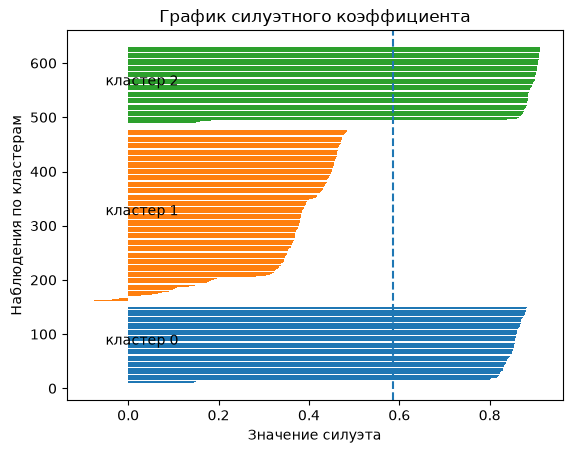

In [15]:
K = len(np.unique(labels))  # сохраняем уникальные метки кластеров в отдельный список
y_lower = 10				# сдвиг графиков по разным кластерам - чтобы красиво выглядело
for c in range(K):          # цикл по меткам кластеров
    vals_c = sil_each[labels == c]  # для каждой метки извлекаем силуэты объектов с этой меткой
    vals_c.sort()					# сортируем значения

    y_upper = y_lower + len(vals_c)  # сдвиг - чтобы графики не накладывались друг на друга
    plt.barh(range(y_lower, y_upper), vals_c)  # отрисовываем график - горизонтальные бары
    plt.text(-0.05, (y_lower + y_upper) / 2, f"кластер {c}")  # подписи графика

    y_lower = y_upper + 10  # обновляем значение сдвига

plt.axvline(x=sil_avg, linestyle="--")  # добавляем на график среднее значение силуэта по всей выборке
plt.title("График силуэтного коэффициента")
plt.xlabel("Значение силуэта")
plt.ylabel("Наблюдения по кластерам")
plt.show()   # отображаем получившийся график

## Метод локтя

In [20]:
ks = range(2, 12)
wcss = [] 

In [21]:
for k in ks:
    # Для каждого количества кластеров k обучаем пайплайн модели
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("kmeans", KMeans(n_clusters=k, random_state=42))  # n_clusters=k — здесь 
    ])
    pipe.fit(X)

    inertia = pipe.named_steps["kmeans"].inertia_  # Получаем WCSS из обученного пайплайна
    wcss.append(inertia)  # Добавляем новое значение WCSS в общий список

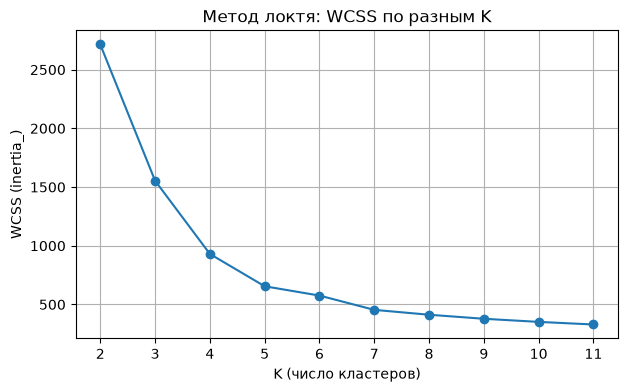

In [22]:
# График локтя
plt.figure(figsize=(7, 4))
plt.plot(list(ks), wcss, marker="o")  # График — обычная линия с количеством кластеров на оси X и значениями WCSS на оси Y
plt.xticks(list(ks))  # Метки на оси X — количество кластеров, для которого считали WCSS в цикле
plt.xlabel("K (число кластеров)")
plt.ylabel("WCSS (inertia_)")
plt.title("Метод локтя: WCSS по разным K")
plt.grid(True)
plt.show()